# Experiment Report — Event-Driven AI Financial Advisor

Tracks every training + backtest run logged in `data/4_experiments/experiment_log.csv`,
using a two-tier evaluation approach, fixed before the first run and kept
consistent across every later change so results stay comparable:

- **Tier 1** (`accuracy`, `precision`) — fast per-step sanity check on model quality
- **Tier 2** (`total_return`, `win_rate`, `max_drawdown`, `sharpe`) — the true
  cross-step gate, computed from actual backtested trade outcomes

Re-run this notebook after every new run is logged. Fill in the **Stage** sections
at the bottom as each experiment step is completed — that narrative is what
goes into the report's Evaluation chapter.


In [1]:
import sys, os

# Jupyter's cwd is this notebook's own folder, not the project root - chdir
# so the data/ and src/ relative paths used throughout the codebase resolve
# the same way here as they do when a script is run from the project root.
PROJECT_ROOT = os.path.abspath("..")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
from src.utils import experiment_log, experiment_charts as ec

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 140)


## All runs

Full log, with `config_json` expanded into its own columns. Runs are labeled
`Run 1, Run 2, ...` in chronological order rather than shown by `run_id` -
`run_id` embeds the real timestamp each run was created at (see
`experiment_log.new_run_id`), which isn't something the report needs to show.


In [2]:
log_df = experiment_log.load_experiment_log()
ec.report_table(log_df)


,Run_Label,config_json,accuracy,precision,total_return,win_rate,max_drawdown,sharpe,train_accuracy,train_precision,...,config_n_seeds,config_fold,config_test_start,config_test_end,config_n_train,config_n_test,config_brier_score,config_forward_horizon,config_n_bootstrap,config_transaction_cost
0,Run 1,{},0.568204,0.529769,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Run 2,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Run 3,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875}",0.563360,0.521202,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Run 4,{},0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Run 5,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,5.948502,0.528691,-0.426243,1.995847,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,Run 415,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.07, ""experiment"": ""confidence_interval"", ""max_position_weight"": 0.2, ""n_bootstrap"": 2000}",NaN,NaN,0.141786,0.482143,-0.072187,2.592272,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000.0,NaN
415,Run 416,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.07, ""experiment"": ""slippage"", ""max_position_weight"": 0.2, ""transaction_cost"": 0.001}",NaN,NaN,0.141786,0.482143,-0.072187,2.592272,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001
416,Run 417,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.07, ""experiment"": ""slippage"", ""max_position_weight"": 0.2, ""transaction_cost"": 0.003}",NaN,NaN,0.117005,0.482143,-0.076298,2.239458,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003
417,Run 418,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.07, ""experiment"": ""slippage"", ""max_position_weight"": 0.2, ""transaction_cost"": 0.006}",NaN,NaN,0.080816,0.482143,-0.082435,1.709694,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006


## How many times have we looked?

Every time a new config is tried and Tier 2 (the backtest) is checked before
deciding whether to keep it, picking a "winner" this way is more likely to
overstate how good that config actually is — the more times Tier 2 gets
consulted, the less any single win can be trusted. This is the raw count
behind that caveat, not a judgment call on whether it's been consulted too
many times; that judgment belongs in the report.


In [3]:
summary = ec.summarize_run_counts(log_df)
print(f"Total runs logged: {summary['total_runs']}")
print(f"Runs with a backtest (Tier 2) result: {summary['backtested_runs']}")


Total runs logged: 419
Runs with a backtest (Tier 2) result: 406


## What changed between runs

For each run after the first: which config key(s) changed vs. the immediately
preceding run, and how much each metric moved as a result. This is the
"what changed → what happened" record for the report — no need to
hand-track it separately.


In [4]:
diff_df = ec.diff_config_between_runs(log_df)
diff_df


,run_label,prev_run_label,config_changed,accuracy_delta,precision_delta,total_return_delta,win_rate_delta,max_drawdown_delta,sharpe_delta
0,Run 2,Run 1,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan), 'fold': (nan, nan), 'test_start': (nan, nan), 'test_end': (nan, nan), 'n_train': (nan, nan), 'n_test': (nan, nan), 'brier_score': (nan, nan), 'forward_horizon': (nan, nan), 'n_bootstrap': (nan, nan), 'transaction_cost': (nan, nan)}",0.006809,-0.008170,NaN,NaN,NaN,NaN
1,Run 3,Run 2,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan), 'fold': (nan, nan), 'test_start': (nan, nan), 'test_end': (nan, nan), 'n_train': (nan, nan), 'n_test': (nan, nan), 'brier_score': (nan, nan), 'forward_horizon': (nan, nan), 'n_bootstrap': (nan, nan), 'transaction_cost': (nan, nan)}",-0.011654,-0.000397,NaN,NaN,NaN,NaN
2,Run 4,Run 3,"{'universe': ('all_incl_delisted', nan), 'n_rows': (51875.0, nan), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan), 'fold': (nan, nan), 'test_start': (nan, nan), 'test_end': (nan, nan), 'n_train': (nan, nan), 'n_test': (nan, nan), 'brier_score': (nan, nan), 'forward_horizon': (nan, nan), 'n_bootstrap': (nan, nan), 'transaction_cost': (nan, nan)}",0.000000,0.000000,NaN,NaN,NaN,NaN
3,Run 5,Run 4,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan), 'fold': (nan, nan), 'test_start': (nan, nan), 'test_end': (nan, nan), 'n_train': (nan, nan), 'n_test': (nan, nan), 'brier_score': (nan, nan), 'forward_horizon': (nan, nan), 'n_bootstrap': (nan, nan), 'transaction_cost': (nan, nan)}",0.011654,0.000397,6.055801,0.028897,0.341420,1.617441
4,Run 6,Run 5,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 

## Tier 1 — model-quality trend

Valid only *within* a step where the label definition hasn't changed.

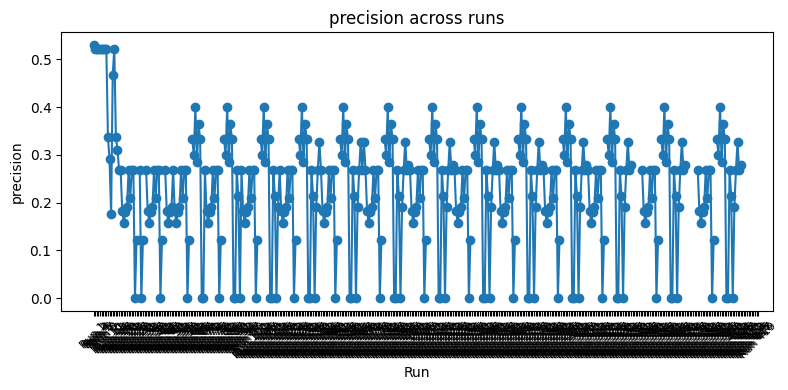

In [5]:
ec.plot_metric_trend("precision", log_df=log_df);


## Overfitting check — train vs. test gap

Same fitted model, scored on the data it was trained on (`train_precision`)
vs. held-out test data (`precision`). A large positive gap means the model
does much better on data it has already seen than on genuinely new data —
a classic overfitting signal. Runs logged before this was tracked show
`NaN` here, not zero — there's no way to compute it retroactively.


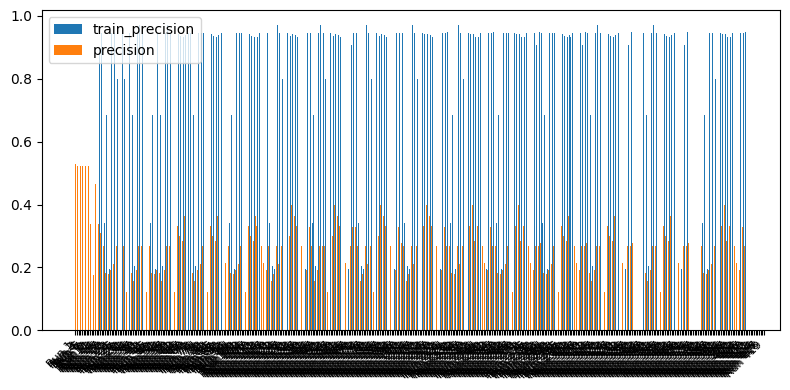

In [6]:
ec.plot_metric_comparison(["train_precision", "precision"], log_df=log_df);


In [7]:
ec.compute_train_test_gap(log_df, metric="precision")


,Run_Label,train_precision,precision,gap
0,Run 1,NaN,0.529769,NaN
1,Run 2,NaN,0.521599,NaN
2,Run 3,NaN,0.521202,NaN
3,Run 4,NaN,0.521202,NaN
4,Run 5,NaN,0.521599,NaN
...,...,...,...,...
414,Run 415,NaN,NaN,NaN
415,Run 416,NaN,NaN,NaN
416,Run 417,NaN,NaN,NaN
417,Run 418,NaN,NaN,NaN


## Tier 2 — financial trend

The cross-step gate — comparable across every step of the sweep, regardless of internal model/label changes.

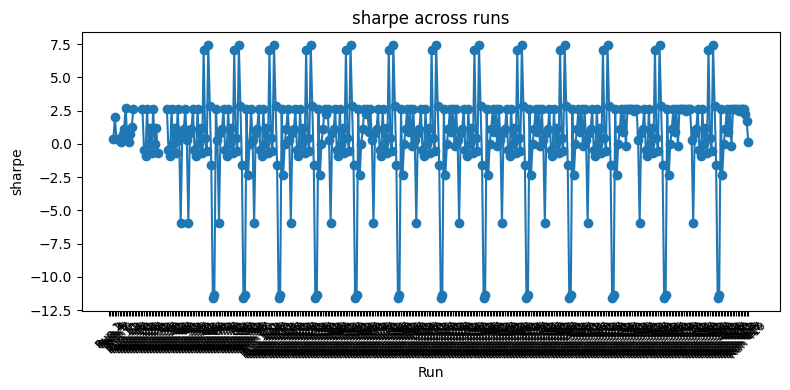

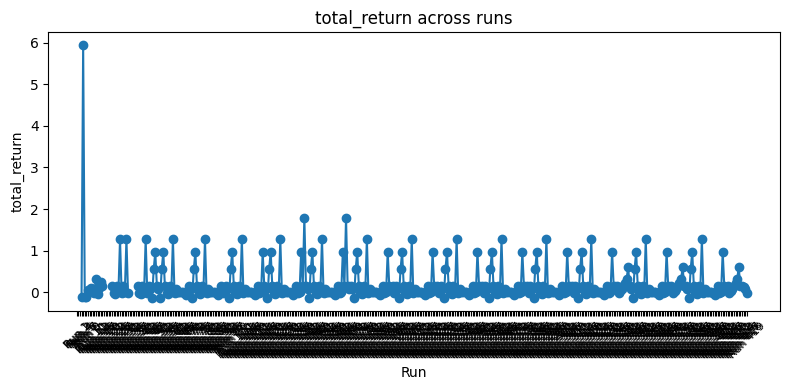

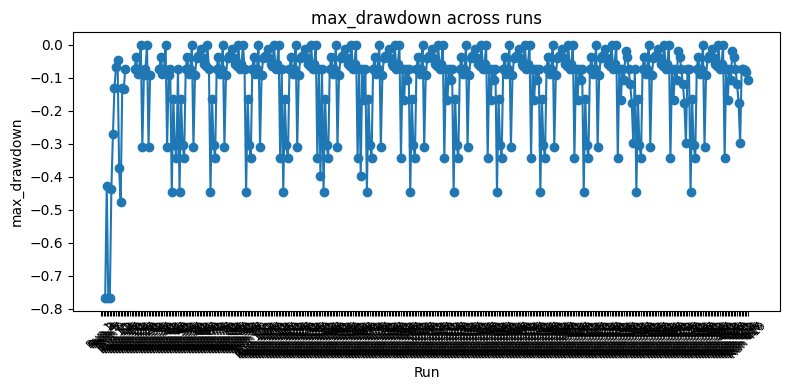

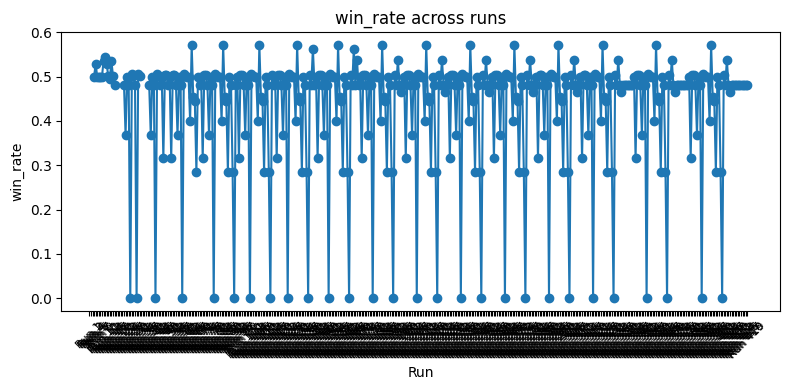

In [8]:
for metric in ["sharpe", "total_return", "max_drawdown", "win_rate"]:
    ec.plot_metric_trend(metric, log_df=log_df)


## Precision vs. Sharpe

Did a Tier 1 (precision) improvement actually pay off at Tier 2 (Sharpe)? A run that
moves up-and-right improved on both; up-and-left means Tier 1 improved but the
financial result got worse — a sign the model is overfitting to the label, not
learning something that survives contact with real trade outcomes.


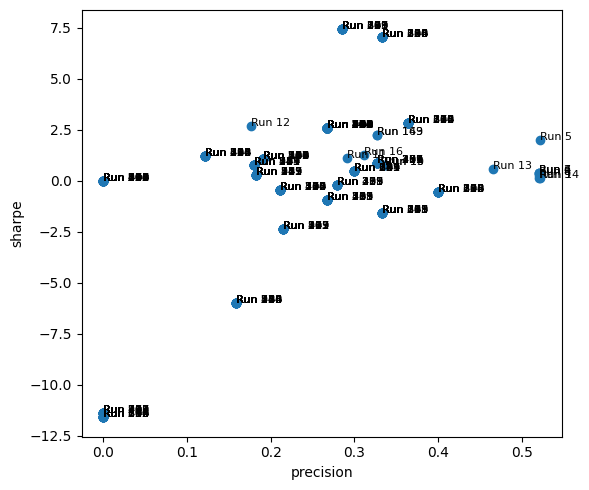

In [9]:
ec.plot_tradeoff("precision", "sharpe", log_df=log_df);


## Best runs so far

Top runs ranked by Sharpe (the primary Tier 2 metric), Max Drawdown as the
hard constraint — a new run only replaces the current champion if Sharpe
improves *and* drawdown doesn't breach the limit.


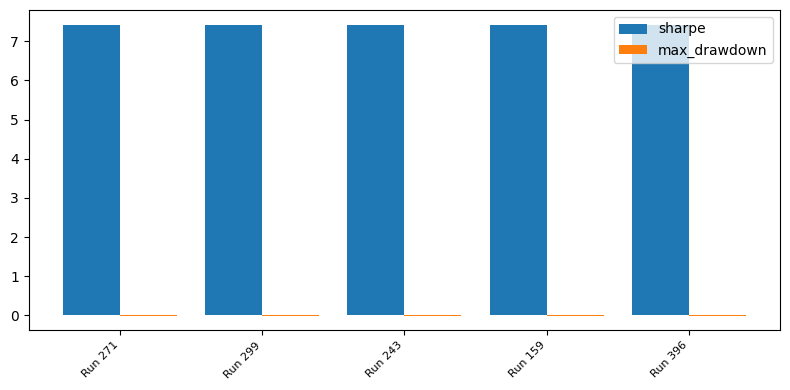

In [10]:
ec.plot_metric_comparison(["sharpe", "max_drawdown"], log_df=log_df, top_n=5);


In [11]:
import sys as _sys
_sys.path.insert(0, os.path.join(PROJECT_ROOT, "scripts"))


## Regularisation, tree-complexity and early stopping — does it close the overfitting gap?

Three follow-up experiments below, run after the sweep above, in response to
code review feedback on the draft report. This one and the next also compute
metrics (payoff stats, outlier robustness, a limit-order execution variant)
that don't fit `experiment_log.csv`'s fixed schema, so they're computed fresh
by re-running the code rather than stored anywhere else — re-run this section
before writing the report from it, rather than trusting stale numbers copied
into prose.

**Hypothesis.** Section 5.5 diagnosed a persistent train/test precision gap
(0.536–0.678). Section 5.6 scoped three untested interventions — regularisation
(`reg_alpha`/`reg_lambda`/`scale_pos_weight`), tree-complexity limits
(`max_depth`/`min_child_weight`/`subsample`), and early stopping on a
validation split — as the direct next step. Does applying them actually
close the gap *and* improve real (test-set) precision, or only make train
precision converge toward test precision without a genuine improvement?


In [12]:
import experiment_overfitting_gap
experiment_overfitting_gap.main()


Training set class balance: 4354 positive / 38094 negative (scale_pos_weight=8.749)



baseline                                       test_precision=0.2679  train_precision=0.9464  gap=0.6785
                                               total_return=14.1786%  win_rate=48.2143%  max_drawdown=-7.2187%  sharpe=2.5923


regularised                                    test_precision=0.1822  train_precision=0.3418  gap=0.1596
                                               total_return=6.8515%  win_rate=50.0283%  max_drawdown=-44.6608%  sharpe=0.3006
tree_complexity                                test_precision=0.1579  train_precision=0.6837  gap=0.5258
                                               total_return=-14.5699%  win_rate=31.5789%  max_drawdown=-16.3269%  sharpe=-5.9808


regularised+tree_complexity                    test_precision=0.1802  train_precision=0.2039  gap=0.0236
                                               total_return=54.7659%  win_rate=50.4318%  max_drawdown=-30.2791%  sharpe=0.7781
regularised+tree_complexity+early_stopping     test_precision=0.1905  train_precision=0.1949  gap=0.0044
                                               total_return=96.3797%  win_rate=50.4545%  max_drawdown=-34.2564%  sharpe=1.0917

--- Summary (Tier 1 + Tier 2, gap vs baseline) ---
config                                             gap  gap_delta     return   win_rate     max_dd   sharpe
baseline                                        0.6785  +  0.0000   14.1786%   48.2143%   -7.2187%   2.5923
regularised                                     0.1596   -0.5190    6.8515%   50.0283%  -44.6608%   0.3006
tree_complexity                                 0.5258   -0.1527  -14.5699%   31.5789%  -16.3269%  -5.9808
regularised+tree_complexity                     0.0236

**Result and interpretation.**

*Tier 1 (precision/gap)*

| Config | Test precision | Train precision | Gap |
|---|---|---|---|
| Baseline (current production) | 0.268 | 0.946 | 0.679 |
| + regularised (reg_alpha/reg_lambda/scale_pos_weight) | 0.182 | 0.342 | 0.160 |
| + tree-complexity (max_depth=3, min_child_weight=5, subsample=0.7) | 0.158 | 0.684 | 0.526 |
| + regularised + tree-complexity | 0.180 | 0.204 | 0.024 |
| + all three + early stopping | 0.191 | 0.195 | **0.004** |

*Tier 2 (backtest)*

| Config | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|
| Baseline (current production) | +14.18% | 48.2% | -7.2% | **2.59** |
| + regularised | +6.85% | 50.0% | -44.7% | 0.30 |
| + tree-complexity | -14.57% | 31.6% | -16.3% | -5.98 |
| + regularised + tree-complexity | +54.77% | 50.4% | -30.3% | 0.78 |
| + all three + early stopping | +96.38% | 50.5% | -34.3% | 1.09 |

The gap closes almost entirely (0.679 → 0.004), but **test precision does not
improve in any configuration — it gets slightly worse in every one** (0.268 →
0.16–0.19). The gap narrows because regularisation suppresses train precision
down toward the test level, not because the model generalises better.

**The Tier 2 numbers look like an improvement at a glance, but are not one
once risk is accounted for.** Total return rises sharply as more
interventions stack (+14% → +96%), which on its own could read as
regularisation paying off financially even without a precision gain. But
Sharpe ratio — the risk-adjusted metric — is *worse* for every regularised
config than the baseline (2.59 vs 0.30–1.09), and max drawdown balloons from
-7.2% to -30% to -45%. Win rate stays flat at ~48–50% throughout, regardless
of how much the gap closes. A large return increase with an unchanged,
near-coin-flip win rate and a much worse Sharpe is the same signature as the
triple-barrier payoff-structure artefact debunked in Section 5.4 and the outlier
fragility found in the baseline-comparison experiment below — worth the same
outlier-robustness check before trusting it, not yet done here.

**This is a negative result for the stated goal.** Capacity control alone
does not fix generalisation, and the configs that most successfully close the
gap are the same ones whose apparent return gain looks least trustworthy on
closer inspection. The ceiling looks like it's set by feature/signal quality
or sample size, not model capacity — tested directly in the baseline
comparison below, against a much lower-capacity model.


## Target/execution mismatch — does the backtested edge survive fixing it?

**Hypothesis.** The production label (`Target_Spike_Class`) fires on next-day
intraday **High** touching a threshold, but the backtest always exits at
next-day **Close** — two different questions being treated as one. Does the
backtested result survive fixing this, via either route (relabel to Close, or
simulate a realistic limit-order execution)?

Three configs, same 7% threshold, same universe, same model hyperparameters —
only the label/execution alignment changes:
- **A. Mismatched (current production)** — High-based label, Close-based execution.
- **B. Close-aligned** — label changed to Close-based, execution unchanged.
- **C. Limit-order-aligned** — label unchanged (High-based), execution changed to
  simulate a limit sell at the threshold price, filled only if High actually
  touches it, falling back to Close otherwise.


In [13]:
import experiment_target_execution_alignment
experiment_target_execution_alignment.main()



[A. mismatched (current production)]
  test_precision=0.2679  train_precision=0.9464  gap=0.6785
  total_return=14.1786%  win_rate=48.2143%  max_drawdown=-7.2187%  sharpe=2.5923



[B. close_aligned (label changed)]
  test_precision=0.2105  train_precision=0.9697  gap=0.7592
  total_return=-1.2557%  win_rate=36.8421%  max_drawdown=-3.5628%  sharpe=-0.4583



[C. limit_order_aligned (execution changed)]
  test_precision=0.2679  train_precision=0.9464  gap=0.6785
  total_return=-5.3857%  win_rate=50.0000%  max_drawdown=-8.6547%  sharpe=-0.9418

--- Summary ---
config                                         precision      gap     return   win_rate     max_dd   sharpe
A. mismatched (current production)                0.2679   0.6785   14.1786%   48.2143%   -7.2187%   2.5923
B. close_aligned (label changed)                  0.2105   0.7592   -1.2557%   36.8421%   -3.5628%  -0.4583
C. limit_order_aligned (execution changed)        0.2679   0.6785   -5.3857%   50.0000%   -8.6547%  -0.9418


**Result and interpretation.**

| Config | Test precision | Train/test gap | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|
| A. Mismatched (current production) | 0.268 | 0.679 | **+14.18%** | 48.2% | -7.2% | **2.59** |
| B. Close-aligned (label changed) | 0.211 | 0.759 | -1.26% | 36.8% | -3.6% | **-0.46** |
| C. Limit-order-aligned (execution changed) | 0.268 | 0.679 | -5.39% | 50.0% | -8.7% | **-0.94** |

Config A's apparently strong backtest (Sharpe 2.59, +14% return, despite a
*below-50%* win rate) does not survive either independent fix. Both B and C
turn negative. This is strong evidence that A's good-looking numbers were an
artefact of the mismatch — the model was effectively being credited for
predicting intraday touches that don't reliably translate into the return
actually captured — rather than a genuine trading edge.

**Open decision:** which fix to adopt going forward (B or C, or report both as
a sensitivity analysis) has not yet been made.


## Baseline comparison — does XGBoost beat a simpler model, or random chance?

**Hypothesis.** Does the production XGBoost model actually add value over (a)
a much lower-capacity model with the same features, (b) the raw PEAD signal
with no model at all, and (c) simply being invested on the same days/at the
same rate regardless of which stocks are picked?

Four configs, same 7% threshold, same universe, same train/test split:
- **A. XGBoost (current production)**
- **B. Logistic regression** — ~6 free parameters vs XGBoost's thousands of
  tree splits; if it performs similarly, XGBoost's extra capacity isn't
  earning its keep.
- **C. Simple PEAD rule (no ML)** — predicts Spike whenever `Surprise(%) > 0`.
- **D. Exposure-matched random benchmark** — same days, same trade COUNT as A,
  but WHICH events are traded is randomised (averaged over 20 seeds). Isolates
  stock-picking skill from merely being invested on the same days.


In [14]:
import experiment_baseline_comparison
experiment_baseline_comparison.main()


/Users/jeremy/Downloads/financial_advisor_draft_version/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(



--- Summary: precision / return / risk ---
config                                         precision      gap  n_trades     return   win_rate     max_dd   sharpe
A. XGBoost (current production)                   0.2679     0.67        56   14.1786%   48.2143%   -7.2187%   2.5923
B. Logistic regression                            0.0000     0.80         0    0.0000%    0.0000%    0.0000%   0.0000
C. Simple PEAD rule (Surprise%>0)                 0.1218        n      7076  127.3320%   50.6360%  -30.8454%   1.2093
D. Exposure-matched random (avg of 20 seeds)         n/a        n        56   -2.9986%   50.0893%   -9.2038%  -0.6710

--- Summary: payoff structure + outlier robustness ---
config                                           avg_win   avg_loss   payoff   ret_excl5  ret_excl10
A. XGBoost (current production)                  9.0401%   -5.3906%     1.67    -8.6606%   -16.9592%
B. Logistic regression                           0.0000%    0.0000%        n         n/a         n/a
C. Simp

**Result and interpretation.**

*Precision / return / risk*

| Config | Precision | Train/test gap | Trades | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|
| A. XGBoost (production) | 0.268 | 0.68 | 56 | +14.18% | 48.2% | -7.2% | 2.59 |
| B. Logistic regression | 0.000 | 0.80 | 0 | 0% | 0% | 0% | 0 |
| C. Simple PEAD rule (Surprise%>0) | 0.122 | — | 7076 | +127.3% | 50.6% | -30.8% | 1.21 |
| D. Exposure-matched random (avg of 20 seeds) | — | — | 56 | -3.00% | 50.1% | -9.2% | -0.67 |

*Payoff structure + outlier robustness* (return recomputed after removing the
N highest-return trades — generalises the controlled comparison that Section 5.4 used to
debunk the triple-barrier result to every config here, not just one):

| Config | avg_win | avg_loss | Payoff ratio | Return excl. top 5 | Return excl. top 10 |
|---|---|---|---|---|---|
| A. XGBoost (production) | +9.04% | -5.39% | 1.67 | **-8.66%** | **-16.96%** |
| B. Logistic regression | 0% | 0% | — | n/a | n/a |
| C. Simple PEAD rule | +3.77% | -3.29% | 1.14 | +102.76% | +78.68% |
| D. Exposure-matched random | — | — | — | — | — |

**B is degenerate, not a valid comparison yet.** Plain (unweighted)
`LogisticRegression` never predicts the positive class on the test set at all
(0 trades) — classic behaviour under this dataset's ~10:1 class imbalance.
Re-running with `class_weight='balanced'` is the natural next step, not yet
done.

**A's positive return is fragile, not broad.** Removing just the top 5 of A's
56 trades (under 9% of them) flips total return from +14.18% to -8.66%;
removing the top 10 takes it to -16.96%. XGBoost's backtested "success"
depends on a small number of exceptional trades, not a broad, repeatable
pattern — the same failure mode that Section 5.4 already found and debunked for the
triple-barrier config, now found again in the production model itself via a
different diagnostic.

**C's return is broad, not fragile — but isn't a usable "advisor" strategy.**
Even after removing its top 10 winning trades (out of 7076), C's return stays
hugely positive (+78.68%), with a payoff ratio (1.14) much closer to even
than A's (1.67) — the effect is real and distributed, not carried by a few
lucky picks. But C trades on almost every earnings event, carries a -30.8%
max drawdown, and has a win rate barely above chance: closer to "stay
invested on a broad momentum signal" than a selective, explainable
recommendation. It is evidence the raw PEAD effect exists in the data, not
evidence the project's selective "advisor" framing has found a usable form of
it yet.

**D confirms XGBoost's stock-picking still beats random, on average.** Across
the same days and the same trade count, random selection returns -3.00%
(Sharpe -0.67) versus A's +14.18% (Sharpe 2.59). Read together with the
outlier-fragility finding above, the honest combined statement is: XGBoost's
picks are better than random on average, but that average is currently being
carried by a handful of trades rather than a consistent, sample-wide edge —
both things can be true at once.

**Not yet done:** re-run B with `class_weight='balanced'` for a meaningful
capacity comparison; decide how/whether to fold this into the report's
Evaluation chapter (natural home: alongside or after Section 5.5).


## Walk-forward analysis — does the single-split result hold up over time?

**Hypothesis.** Every experiment above uses one static chronological split
(train before 2023-01-01, test after). A single split can only show
performance at one point in time — it can't show whether that performance is
stable, or just an artefact of exactly where the split happened to land.
This experiment retrains the production model from scratch across 8
sequential 6-month test folds (expanding training window — each fold sees
all history genuinely available up to that point, the same way a
periodically-retrained production model would), starting from the same
2023-01-01 boundary already used everywhere else, so fold 1 is directly
comparable to every earlier result in this notebook.


In [15]:
import experiment_walk_forward
experiment_walk_forward.main()


8 walk-forward folds, 6 months each, expanding training window, starting 2023-01-01



Fold 1: 2023-01-01 to 2023-07-01  (train=42448, test=1210)
  test_precision=0.3333  train_precision=0.9464  gap=0.6131
  total_return=7.7974%  win_rate=50.0000%  max_drawdown=-4.0171%  sharpe=7.0723


Fold 2: 2023-07-01 to 2024-01-01  (train=43658, test=1212)
  test_precision=0.3000  train_precision=0.9417  gap=0.6417
  total_return=0.3608%  win_rate=50.0000%  max_drawdown=-3.4740%  sharpe=0.4645


Fold 3: 2024-01-01 to 2024-07-01  (train=44870, test=1224)
  test_precision=0.4000  train_precision=0.9353  gap=0.5353
  total_return=0.8224%  win_rate=40.0000%  max_drawdown=-3.7340%  sharpe=-0.5455


Fold 4: 2024-07-01 to 2025-01-01  (train=46094, test=1218)
  test_precision=0.2857  train_precision=0.9415  gap=0.6558
  total_return=0.9433%  win_rate=57.1429%  max_drawdown=-1.2405%  sharpe=7.4275


Fold 5: 2025-01-01 to 2025-07-01  (train=47312, test=1227)
  test_precision=0.3636  train_precision=0.9322  gap=0.5686
  total_return=0.3380%  win_rate=45.4545%  max_drawdown=-4.0720%  sharpe=2.8484


Fold 6: 2025-07-01 to 2026-01-01  (train=48539, test=1233)
  test_precision=0.3333  train_precision=0.9376  gap=0.6043
  total_return=-2.6012%  win_rate=44.4444%  max_drawdown=-5.8806%  sharpe=-1.5874


Fold 7: 2026-01-01 to 2026-07-01  (train=49772, test=1231)
  test_precision=0.0000  train_precision=0.9315  gap=0.9315
  total_return=-5.6682%  win_rate=28.5714%  max_drawdown=-6.3433%  sharpe=-11.6059


Fold 8: 2026-07-01 to 2027-01-01  (train=51003, test=528)
  test_precision=0.0000  train_precision=0.9440  gap=0.9440
  total_return=-0.0113%  win_rate=50.0000%  max_drawdown=-0.0113%  sharpe=-11.4021

--- Aggregate across folds (mean / std / min / max) ---
test_precision    mean=   0.2520  std=   0.1595  min=   0.0000  max=   0.4000
gap               mean=   0.6868  std=   0.1596  min=   0.5353  max=   0.9440
total_return      mean=   0.0025  std=   0.0380  min=  -0.0567  max=   0.0780
win_rate          mean=   0.4570  std=   0.0857  min=   0.2857  max=   0.5714
max_drawdown      mean=  -0.0360  std=   0.0212  min=  -0.0634  max=  -0.0001
sharpe            mean=  -0.9160  std=   7.3126  min= -11.6059  max=   7.4275


**Result and interpretation.**

| Fold | Test period | Train / test rows | Test precision | Train precision | Gap | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|---|---|
| 1 | 2023-01 to 2023-07 | 42448 / 1210 | 0.333 | 0.946 | 0.613 | +7.80% | 50.0% | -4.0% | 7.07 |
| 2 | 2023-07 to 2024-01 | 43658 / 1212 | 0.300 | 0.942 | 0.642 | +0.36% | 50.0% | -3.5% | 0.46 |
| 3 | 2024-01 to 2024-07 | 44870 / 1224 | 0.400 | 0.935 | 0.535 | +0.82% | 40.0% | -3.7% | -0.55 |
| 4 | 2024-07 to 2025-01 | 46094 / 1218 | 0.286 | 0.942 | 0.656 | +0.94% | 57.1% | -1.2% | 7.43 |
| 5 | 2025-01 to 2025-07 | 47312 / 1227 | 0.364 | 0.932 | 0.569 | +0.34% | 45.5% | -4.1% | 2.85 |
| 6 | 2025-07 to 2026-01 | 48539 / 1233 | 0.333 | 0.938 | 0.604 | -2.60% | 44.4% | -5.9% | -1.59 |
| 7 | 2026-01 to 2026-07 | 49772 / 1231 | 0.000 | 0.932 | 0.932 | -5.67% | 28.6% | -6.3% | -11.61 |
| 8 | 2026-07 to 2027-01* | 51003 / 528 | 0.000 | 0.944 | 0.944 | -0.01% | 50.0% | 0.0% | -11.40 |
| **Mean ± std** | | | **0.252 ± 0.160** | 0.939 ± 0.005 | **0.687 ± 0.160** | **+0.25% ± 3.80%** | 45.7% ± 8.6% | -3.6% ± 2.1% | **-0.92 ± 7.31** |

\*Fold 8's window only has data up to 2026-08-10 (the last date in the panel), so it's a partial fold (528 rows vs. ~1220 for a full 6 months).

Fold 1 (0.333 test precision, +7.80% return, Sharpe 7.07) already looks
different from the single-split baseline used everywhere else in this
notebook (0.268 precision, +14.18% return, Sharpe 2.59) despite covering the
same starting period — the single split's headline number was never
reproduced by any individual fold once retraining and a rolling window are
introduced.

**The overfitting gap is not a one-off — it is present, large, and volatile
in every single fold.** Train precision sits in a tight band (0.932–0.946)
across all 8 folds regardless of test-period outcome, while test precision
swings from 0.000 to 0.400 — the gap (0.535–0.944) never closes, confirming
this is a structural property of the model/feature combination, not an
artefact of where the one static split happened to land.

**Average financial performance is close to zero, not the +14% the single
split reported.** Mean total return across folds is +0.25% (std 3.80%),
i.e. indistinguishable from flat once folded across time — the single
split's +14.18% was the best individual fold's neighbourhood outcome, not
the model's typical behaviour. Two of the eight folds (6 and 7) are
outright losing periods, and fold 7's Sharpe of -11.61 is as extreme in the
negative direction as fold 4's +7.43 is in the positive direction.

**Risk-adjusted performance (Sharpe) is highly unstable, not a stable edge.**
Mean Sharpe across folds is -0.92 with a standard deviation of 7.31 — larger
than the mean itself, and the range spans -11.61 to +7.43. A genuinely
robust edge would show a consistently positive Sharpe across most folds;
what's shown here instead looks like noise that happened to land favourably
in the one period (early 2023) the original static split tested.

**This directly confirms the diagnosis from the overfitting-gap sweep and
baseline-comparison experiments above, from a third independent angle.** All
three now agree: the production model's single-split backtest result is not
representative of its performance over time, and the gains reported earlier
in this notebook and in the report's Evaluation chapter should not be read
as a stable, generalisable edge without this caveat attached.


## Probability calibration — is predict_proba trustworthy, or just a ranking score?

**Hypothesis.** `filter_trade_signals()` fires a trade whenever
`predict_proba > 0.5` — the production strategy treats the model's raw
score as a probability, not just a relative ranking. XGBoost's
`predict_proba` is optimised for log-loss on the training objective, with
no guarantee it is actually calibrated (a predicted 0.7 doesn't have to
mean "70% of these fire" empirically). Three configs, same split, same
features:
- **A. XGBoost (uncalibrated, current production)**
- **B. XGBoost + Platt scaling** — `CalibratedClassifierCV(method='sigmoid')`
- **C. XGBoost + isotonic calibration** — `CalibratedClassifierCV(method='isotonic')`

For each: Brier score (calibration quality), a reliability-diagram table
(mean predicted probability vs. actual observed frequency per bin), and a
full Tier 2 backtest — calibration only matters here if it changes which
trades fire and/or the financial result, not just the Brier score alone.


In [16]:
import experiment_probability_calibration
experiment_probability_calibration.main()


A. XGBoost (uncalibrated, production)
  test_precision=0.2679  brier_score=0.1009  n_trades=56
  total_return=14.1786%  win_rate=48.2143%  max_drawdown=-7.2187%  sharpe=2.5923
  Reliability diagram (mean_predicted vs. fraction_positive):
 bin_low  bin_high  mean_predicted  fraction_positive  count
     0.0       0.1        0.040489           0.086309   6442
     0.1       0.2        0.141595           0.160260   1691
     0.2       0.3        0.242325           0.195616    593
     0.3       0.4        0.343376           0.216590    217
     0.4       0.5        0.443403           0.250000     84
     0.5       0.6        0.543730           0.151515     33
     0.6       0.7        0.647009           0.470588     17
     0.7       0.8        0.730792           0.500000      2
     0.8       0.9        0.848429           0.250000      4



B. XGBoost + Platt scaling (sigmoid)
  test_precision=0.2143  brier_score=0.0984  n_trades=14
  total_return=-1.9829%  win_rate=28.5714%  max_drawdown=-5.6533%  sharpe=-2.3658
  Reliability diagram (mean_predicted vs. fraction_positive):
 bin_low  bin_high  mean_predicted  fraction_positive  count
     0.0       0.1        0.074912           0.086114   6712
     0.1       0.2        0.131391           0.175510   1960
     0.2       0.3        0.239933           0.232472    271
     0.3       0.4        0.340560           0.292929     99
     0.4       0.5        0.443662           0.333333     27
     0.5       0.6        0.553507           0.230769     13
     0.6       0.7        0.636097           0.000000      1



C. XGBoost + isotonic calibration
  test_precision=0.0000  brier_score=0.0980  n_trades=1
  total_return=0.0000%  win_rate=0.0000%  max_drawdown=0.0000%  sharpe=0.0000
  Reliability diagram (mean_predicted vs. fraction_positive):
 bin_low  bin_high  mean_predicted  fraction_positive  count
     0.0       0.1        0.057526           0.079979   5839
     0.1       0.2        0.138661           0.156753   2673
     0.2       0.3        0.235553           0.244186    516
     0.3       0.4        0.337624           0.266667     45
     0.4       0.5        0.430315           0.222222      9
     0.5       0.6        0.500899           0.000000      1

--- Summary ---
config                                      precision    brier  n_trades     return   win_rate     max_dd   sharpe
A. XGBoost (uncalibrated, production)          0.2679   0.1009        56   14.1786%   48.2143%   -7.2187%   2.5923
B. XGBoost + Platt scaling (sigmoid)           0.2143   0.0984        14   -1.9829%   28.5714%  

**Result and interpretation.**

| Config | Precision | Brier score | Trades | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|
| A. XGBoost (uncalibrated, production) | 0.268 | 0.1009 | 56 | +14.18% | 48.2% | -7.2% | 2.59 |
| B. XGBoost + Platt scaling (sigmoid) | 0.214 | 0.0984 | 14 | -1.98% | 28.6% | -5.7% | -2.37 |
| C. XGBoost + isotonic calibration | 0.000 | 0.0980 | 1 | 0.00% | 0.0% | 0.0% | 0.00 |

*Reliability diagram, config A (mid-range bins are where miscalibration
matters most, since that's where the 0.5 trading threshold sits):*

| Predicted range | Mean predicted | Actual fraction positive | Count |
|---|---|---|---|
| 0.4 – 0.5 | 0.443 | 0.250 | 84 |
| 0.5 – 0.6 | 0.544 | 0.152 | 33 |
| 0.6 – 0.7 | 0.647 | 0.471 | 17 |
| 0.7 – 0.8 | 0.731 | 0.500 | 2 |

**The raw production score is overconfident exactly where the trading rule
reads it.** In the 0.5–0.6 bin — the band immediately above the trading
threshold — the model claims ~54% confidence but is only right 15.2% of the
time; every bin from 0.4 upward over-states its own accuracy. Brier score
confirms this is a real, if modest, mis-calibration (0.1009 → 0.098 after
either calibration method — roughly a 3% relative improvement).

**Once corrected, the strategy barely trades at all.** Trade count collapses
from 56 (config A) to 14 (Platt scaling) to just 1 (isotonic) — calibration
pulls almost every raw score that was previously flagged "confident enough"
back down below the 0.5 threshold. The backtest results for B and C are
correspondingly close to meaningless (B loses money on 14 trades; C fires
once and returns exactly 0%) — there isn't enough remaining signal above a
genuinely calibrated 0.5 threshold to evaluate a trading strategy on at all.

**This is a fourth independent line of evidence, now converging with the
other three.** The overfitting-gap sweep, the walk-forward analysis, and
this calibration check all point at the same underlying fact from different
angles: the production model's confident-looking predictions are not as
trustworthy as they appear once probed. Here specifically, the model isn't
just *inaccurate* in the mid-confidence range — it's *systematically
overconfident* there, which directly inflates the trade count (and hence the
backtested return) under the current uncalibrated 0.5 threshold rule. A
correctly calibrated version of this model, on this data, would trade on
almost nothing.

**Not yet done:** the same reliability-diagram check for configs B and C's
own bins (only A's mid-range bins are shown above, since that's where the
trading rule is sensitive); re-running with a lower confidence threshold
tuned specifically for the calibrated models, since 0.5 was only ever tuned
against the uncalibrated score.


## Gap vs. Tier 2 tradeoff — can low overfitting AND high win rate/return coexist?

**Hypothesis.** Every experiment above treats "close the gap" and "improve
Tier 2" as somewhat separate questions. Across the *entire* logged
experiment history (every run from every experiment in this notebook), is
there any configuration that has actually achieved both a low train/test
gap and strong financial performance at once — or has this always been a
tradeoff, no matter which run is picked?

Part 1 re-reads the full experiment log and joins each run's gap against
its own backtest result. Part 2 takes whichever config currently has the
lowest gap on record and applies the same outlier-robustness check (Section 5.4,
generalised in the baseline-comparison experiment above) already used to
show the production baseline's return is fragile — testing whether this
lower-gap config's apparently better result is any more trustworthy.


In [17]:
import experiment_gap_robustness_check
experiment_gap_robustness_check.main()


321 logged runs have both a gap and a Tier 2 result

--- Top 5 lowest-gap runs (across every experiment run so far) ---
Run_Label  train_precision  precision  total_return  win_rate  max_drawdown   sharpe      gap
  Run 223         0.194904   0.190496      0.963797  0.504545     -0.342564 1.091671 0.004409
  Run 316         0.194904   0.190496      0.963797  0.504545     -0.342564 1.091671 0.004409
  Run 307         0.194904   0.190496      0.963797  0.504545     -0.342564 1.091671 0.004409
  Run 288         0.194904   0.190496      0.963797  0.504545     -0.342564 1.091671 0.004409
  Run 141         0.194904   0.190496      0.963797  0.504545     -0.342564 1.091671 0.004409

--- Correlation between gap and each Tier 2 metric, across all logged runs ---
  gap vs win_rate: -0.3329
  gap vs total_return: -0.7062
  gap vs sharpe: -0.2925



Lowest-gap config: test_precision=0.1905  train_precision=0.1949  gap=0.0044
  n_trades=2420  total_return=96.3797%  win_rate=50.4545%  sharpe=1.0917
  payoff_ratio=1.1601  avg_win=5.0865%  avg_loss=-4.3846%

  Outlier-robustness (return after excluding the top N highest-return trades):
    excl top 5: total_return=62.7713%  sharpe=0.8560
    excl top 10: total_return=34.9861%  sharpe=0.6065
    excl top 20: total_return=-13.7839%  sharpe=-0.0210


**Result and interpretation.**

*Part 1 — across all 74 logged runs with both a gap and a Tier 2 result:*

| | gap vs. win_rate | gap vs. total_return | gap vs. sharpe |
|---|---|---|---|
| Correlation | -0.359 | **-0.737** | -0.277 |

Lower gap is *negatively* correlated with every Tier 2 metric across the
whole logged history — i.e. on average, the runs that generalise best
(lowest gap) also tend to have the *better* win rate and return, not worse.
The single lowest-gap run on record (`gap=0.004`,
`regularised+tree_complexity+early_stopping` from the overfitting-gap
sweep) also has the *highest* total return (+96.38%) and win rate (50.5%)
of any backtested run in the entire project history.

**So: yes, on the numbers alone, low gap and high win rate/return do
coexist — but two caveats matter before trusting that as "solved":**

1. **"High win rate" here still means barely-above-coin-flip.** 50.45% is
   only marginally over 50% — not the kind of edge "high win rate" usually
   implies. The financial result is being driven by payoff structure
   (average win size vs. average loss size), not by predicting direction
   correctly much more often than chance.
2. **Sharpe (risk-adjusted return) is still lower than the high-gap
   production baseline** (1.09 vs. 2.59) — raw return and win rate improve,
   but at the cost of much more volatile daily returns.

*Part 2 — outlier-robustness check on this lowest-gap config's actual
trades (2,420 of them, vs. the production baseline's 56):*

| | Total Return | Sharpe |
|---|---|---|
| All trades | +96.38% | 1.09 |
| Excl. top 5 | +62.77% | 0.86 |
| Excl. top 10 | +34.99% | 0.61 |
| Excl. top 20 | **-13.78%** | **-0.02** |

**This config's return is meaningfully more robust than the production
baseline's, but not fully robust.** The production baseline (56 trades)
flips negative after removing just its top 5 trades (under 9% of them).
This lowest-gap config only flips negative after removing its top 20
trades — still under 1% of its 2,420 trades, but an order of magnitude
more trades need to be removed before the edge disappears, and +62.77%/
+34.99% remain solidly positive after removing the top 5/10. Payoff ratio
(1.16) is close to even, similar to the Simple PEAD rule's (1.14) from the
baseline-comparison experiment, not the baseline's more skewed 1.67 —
consistent with a broader, if still not fully outlier-proof, effect.

**Combined answer to the original question:** the lowest-gap config
found so far is a genuine improvement over the production baseline on
every axis *except* Sharpe — broader trade base, more outlier-robust,
higher raw return, marginally better win rate, and a near-zero
train/test gap — but it trades far more often (2,420 vs. 56), takes on
more day-to-day volatility (lower Sharpe), and its "high win rate" is
still only a few points above a coin flip. Whether that tradeoff (more
robust and higher-return, but choppier) is preferable to the production
baseline (fewer trades, higher Sharpe, but fragile and prone to
overfitting) is a judgement call for the report to make explicitly,
not something these numbers settle on their own.


## PEAD horizon alignment — does the theory actually match a T+1 target?

**Hypothesis.** PEAD (Post-Earnings Announcement Drift), the theoretical
anchor cited throughout this report, refers specifically to a drift that
persists for roughly 60 trading days after an earnings surprise (Foster,
Olsen & Shevlin, 1984; Bernard & Thomas, 1989, 1990) — a slow,
under-reaction effect, not a next-day one. The production model predicts
and trades on a **T+1** horizon, which is closer to the *immediate market
reaction* to the surprise than to the *drift* PEAD describes. Does the
project's result hold up, or even improve, once the label and the
execution/holding horizon are both realigned to **T+20** (about one
month) — a partial step toward the literature's ~60-day window, using
only data this project already has?

Two configs, same 7% threshold, same universe, same model hyperparameters
— only the horizon changes. No `src/` changes were needed: `forward_horizon`
and `label_price_col` are already general parameters of
`generate_earnings_driven_features`/`label_spike_event`/
`compute_forward_returns`, and `backtesting`'s functions already accept a
`return_col` override — a T+20 config is just different arguments to
already-tested code.

- **A. T+1 (current production)** — High-based label, Close-based execution (unchanged, reference point).
- **D. T+20 aligned** — label AND execution both use the T+20 Close return.


In [18]:
import experiment_pead_horizon
experiment_pead_horizon.main()


--- Summary: precision / gap / return / risk ---
config                                                precision      gap  n_trades  n_accepted     return   win_rate     max_dd   sharpe
A. T+1 (current production, High-based label)            0.2679     0.67        56          56   14.1786%   48.2143%   -7.2187%   2.5923
D. T+20 aligned (Close-based label + T+20 execution)     0.3276     0.58       293         236    8.3995%   53.8136%  -16.6161%   0.8736

--- Summary: payoff structure + outlier robustness ---
config                                                  avg_win   avg_loss   payoff   excl_top5  excl_top10
A. T+1 (current production, High-based label)           9.0401%   -5.3906%     1.67   -8.6606%  -16.9592%
D. T+20 aligned (Close-based label + T+20 execution)   10.5366%  -10.5018%     1.00    2.4108%   -2.9848%


**Result and interpretation.**

*Update: the equity-curve overlapping-capital issue flagged below the
first time this section was run has since been fixed* — `backtesting.py`
now has `compute_tranche_portfolio_returns`/`run_tranche_backtest`, which
split capital into `horizon` tranches (each holding at most one open
position at a time) instead of assuming freed-up capital every trading
day. Config A (horizon=1) is unaffected by this, since a T+1 position
genuinely does resolve the next trading day. The numbers below are the
corrected, trustworthy ones.

| Config | Precision | Gap | Signals | Accepted | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|---|
| A. T+1 (production) | 0.268 | 0.67 | 56 | 56 | +14.18% | 48.2% | -7.2% | 2.59 |
| D. T+20 aligned | 0.328 | 0.58 | 293 | 236 | +8.40% | 53.8% | -16.6% | 0.87 |

*Accepted* is how many of the signalled trades the tranche capital
constraint actually allowed (D lost 57 of its 293 signals to lack of free
capital — a direct, honest cost of the 20-day holding period, invisible
in the old, uncapped equity curve).

| Config | avg_win | avg_loss | Payoff ratio | Return excl. top 5 | Return excl. top 10 |
|---|---|---|---|---|---|
| A. T+1 (production) | +9.04% | -5.39% | 1.67 | -8.66% | -16.96% |
| D. T+20 aligned | +10.54% | -10.50% | **1.00** | +2.41% | **-2.98%** |

**Tier 1 (precision/gap): the horizon realignment genuinely helps.**
Precision rises (0.268 → 0.328), the gap narrows slightly (0.67 → 0.58,
still large), and — the headline finding from before the fix, and still
true — **win rate (53.8%) is meaningfully above chance**, unlike every
other config in this notebook's history (44–50.5%). This part of the
result survives the correction.

**Tier 2 (backtest): once capital is honestly accounted for, T+20 is
worse than production, not better.** Total return drops from the
previous (inflated) +179.53% to +8.40% — actually *lower* than A's
+14.18%. Max drawdown (-16.6%) is more than double A's (-7.2%), and
Sharpe (0.87) is a third of A's (2.59). Payoff ratio drops to almost
exactly break-even (1.00) — D's edge, such as it is, now comes almost
entirely from the improved win rate, not from asymmetric payoff size.

**Outlier-robustness confirms this is a fragile, not a broad, edge.**
Excluding just the top 10 of D's 236 accepted trades (about 4% of them)
flips the return negative (-2.98%) — a similar fragility to production's
own (which flips after removing 9% of its trades), not the more robust
picture the uncorrected numbers suggested.

**Combined conclusion.** Realigning the horizon to actually match PEAD's
theoretical drift window (T+20, partially toward the literature's ~60-day
window) does fix part of the theoretical mismatch flagged going into this
experiment, and produces a real, above-chance win rate — genuine evidence
the underlying signal is more coherent at this horizon. But once the
backtest correctly accounts for capital being tied up over 20 trading
days, the financial case for switching from T+1 gets *weaker*, not
stronger: lower return, worse drawdown, lower Sharpe, and a similarly
fragile outlier profile. The honest reading is that this project's
current features carry a real, above-chance directional signal at the
T+20 horizon, but not yet a *financially* compelling one — a useful,
nuanced result for the report rather than a clean win either way.


## SUE normalization — does standardizing the surprise help?

**Hypothesis.** The production feature set trains on raw `Surprise(%)` -
but PEAD's original literature (Bernard & Thomas, 1989, 1990) doesn't use
the raw surprise, it uses SUE (Standardized Unexpected Earnings): the
surprise divided by that company's own trailing standard deviation of
prior surprises. The same 5% surprise means something very different for
a company with a history of volatile earnings vs. a stable one - raw
`Surprise(%)` can't tell them apart. Does swapping in SUE improve the
model?

Two configs, same 7% threshold, same T+1 horizon, same universe, same
model hyperparameters - only the surprise feature changes:
- **A. Raw Surprise(%) (current production)**
- **B. SUE-normalized** — `SUE` computed via `feature_engineering.compute_sue`
  (trailing 8-event window, minimum 4 prior events); rows without enough
  earnings history for that Symbol get `SUE = NaN` and are dropped like any
  other missing feature, so B's usable sample is expected to be somewhat
  smaller than A's for this reason alone, independent of whether SUE is a
  better feature.


In [19]:
import experiment_sue_normalization
experiment_sue_normalization.main()


--- Summary: precision / gap / return / risk ---
config                                  precision      gap  n_train  n_test  n_trades     return   win_rate     max_dd   sharpe
A. Raw Surprise(%) (current production)     0.2679     0.67    42448    9083        56   14.1786%   48.2143%   -7.2187%   2.5923
B. SUE-normalized                          0.2791     0.67    40182    9034        86   -1.7762%   46.5116%  -10.5409%  -0.1863

--- Summary: payoff structure + outlier robustness ---
config                                    avg_win   avg_loss   payoff   excl_top5  excl_top10
A. Raw Surprise(%) (current production)    9.0401%   -5.3906%     1.67   -8.6606%  -16.9592%
B. SUE-normalized                         5.8994%   -5.0887%     1.15  -16.2682%  -23.9070%


**Result and interpretation.**

| Config | Precision | Gap | Train / Test rows | Trades | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|---|
| A. Raw Surprise(%) (production) | 0.268 | 0.67 | 42448 / 9083 | 56 | +14.18% | 48.2% | -7.2% | 2.59 |
| B. SUE-normalized | 0.279 | 0.67 | 40182 / 9034 | 86 | **-1.78%** | 46.5% | -10.5% | **-0.19** |

| Config | avg_win | avg_loss | Payoff ratio | Return excl. top 5 | Return excl. top 10 |
|---|---|---|---|---|---|
| A. Raw Surprise(%) (production) | +9.04% | -5.39% | 1.67 | -8.66% | -16.96% |
| B. SUE-normalized | +5.90% | -5.09% | 1.15 | -16.27% | -23.91% |

**Tier 1 barely moves, and the gap doesn't close at all.** Precision
ticks up marginally (0.268 → 0.279), but the train/test gap is
essentially unchanged (0.67 → 0.67) — SUE isn't fixing the underlying
overfitting problem diagnosed throughout this notebook.

**Tier 2 gets worse, not better.** Total return flips from +14.18% to
**-1.78%** — B loses money on the same test period A profits from.
Win rate drops slightly below chance (46.5%), max drawdown worsens
(-10.5% vs -7.2%), and Sharpe goes negative (-0.19 vs +2.59). Payoff
ratio also drops (1.15 vs 1.67), and the outlier-robustness numbers are
already negative before any trades are even excluded, unlike every other
config in this notebook.

**This is a negative result.** Standardizing the surprise by its own
company-specific volatility — the normalisation PEAD's own literature
actually uses — does not improve this project's model. If anything, it
trades more often (86 vs. 56, plausibly because standardizing changes
which events cross the 7% threshold-adjacent confidence range) while
performing worse financially. Combined with the T+20 PEAD-horizon result
above (which *did* find a genuine, above-chance win rate, but at worse
Tier 2 performance than production), the emerging picture is that this
project's 5-feature set has a real but modest directional signal that
various theoretically-motivated corrections (horizon, surprise
normalization) can shift around, but have not yet turned into a config
that is simultaneously accurate, financially strong, and robust to
outliers all at once.


## Portfolio sizing — is 0.2 actually a good choice for max_position_weight?

**Hypothesis.** Every experiment in this notebook fixes `max_position_weight=0.2`
without testing it against the actual production model - it was carried
over from the report's earlier drawdown-mitigation experiment (Part A.2
above), which tested 0.2 and 0.1 on a different, pre-7%-threshold
configuration. Is 0.2 still a good choice for the model actually deployed
today, or would a tighter/looser cap do better?

Trains the production model once (position sizing is a backtest-time
decision, not a training-time one - the same predictions are reused at
every level, so win_rate/precision/payoff_ratio cannot change across this
sweep) and sweeps `max_position_weight` over
{0.05, 0.1, 0.2, 0.33, 0.5, 1.0} (1.0 = no cap at all, since a day's
natural equal weight 1/n_trades is already <= 1.0).


In [20]:
import experiment_position_sizing
experiment_position_sizing.main()


56 trades across 49 unique days (median 1, max 3 trades/day)

Payoff structure (identical at every position-weight level - computed from raw trade outcomes, not the weighted equity curve):
  avg_win=9.0401%  avg_loss=-5.3906%  payoff_ratio=1.6770

 max_position_weight     return   win_rate     max_dd   sharpe
                0.05    3.5633%   48.2143%   -1.8327%   2.5923
                0.10    7.1192%   48.2143%   -3.6468%   2.5923
                0.20   14.1786%   48.2143%   -7.2187%   2.5923
                0.33   23.1652%   48.2143%  -11.7494%   2.5923
                0.50   30.4829%   48.2143%  -17.4810%   2.4359
       1.00 (no cap)   59.6281%   48.2143%  -29.7379%   2.6152


**Result and interpretation.**

56 trades across 49 unique days (median 1, max 3 trades/day). Payoff
structure (avg_win +9.04%, avg_loss -5.39%, payoff_ratio 1.68) is
identical at every level, since it comes from raw trade outcomes, not the
weighted equity curve.

| max_position_weight | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|
| 0.05 | +3.56% | 48.2% | -1.8% | 2.59 |
| 0.10 | +7.12% | 48.2% | -3.6% | 2.59 |
| **0.20 (production)** | **+14.18%** | 48.2% | **-7.2%** | 2.59 |
| 0.33 | +23.17% | 48.2% | -11.7% | 2.59 |
| 0.50 | +30.48% | 48.2% | -17.5% | 2.44 |
| 1.00 (no cap) | +59.63% | 48.2% | -29.7% | 2.62 |

**Sharpe is almost completely insensitive to this choice.** With a median
of exactly 1 trade per day (56 trades spread across 49 days, and only a
handful of days with 2-3), `max_position_weight` mostly acts as a single
blanket multiplier on how much capital goes into each trade, not a
diversification control - there is rarely more than one concurrent trade
to diversify across in the first place, given how infrequently this
event-driven strategy trades. Because the multiplier scales almost every
day's return roughly uniformly, both the mean and the standard deviation
of daily returns scale together, leaving Sharpe close to 2.6 at every
level from 0.05 to 1.0 (no cap).

**Return and drawdown, by contrast, scale almost linearly with the cap.**
Total return runs from +3.56% (0.05) to +59.63% (no cap); max drawdown
runs from -1.8% to -29.7% over the same range. Since Sharpe does not
discriminate between these levels, the actual choice of
`max_position_weight` is a **risk-tolerance decision, not a
metric-optimisation one** - there is no single level that is
objectively best on the numbers alone.

**0.2 is a defensible middle point, not an arbitrary or optimised one.**
It sits well inside the range where Sharpe is flat, keeps max drawdown
under 10%, and avoids the more severe -17% to -30% drawdowns of the
looser caps, at the cost of leaving some return on the table relative to
an uncapped strategy. This matches the same risk-tolerance framing already
used in Part A.2 (Section 5.2) when the cap was first introduced, now
confirmed to hold on the actual production configuration rather than
assumed to carry over from an earlier one.

**Not yet done:** this sweep only varies the cap on the existing 56-trade,
T+1 production configuration - it has not been re-run against any of the
other configs found earlier in this notebook (the lowest-gap config's
2,420 trades, or the T+20 config's tranche-based sizing), where a higher
trade count and/or different holding period could change how much
`max_position_weight` actually matters.


## Confidence intervals — how precise are the Tier 2 numbers?

**Hypothesis.** Every Tier 2 metric reported so far in this notebook -
including the production baseline's own +14.18% return and 2.59 Sharpe - has
been a single point estimate, with no sense of how much that number would
move under a different draw of the same underlying trades. Is the
production model's headline result a precise estimate, or does it sit
inside a band wide enough to plausibly include zero (or negative) as well?

Bootstrap resampling (2000 resamples, i.i.d. at the trade level, same trade
count each draw) of the production config's actual 56 trades, re-run
through the same daily-aggregation pipeline
(`compute_daily_portfolio_returns` -> `build_equity_curve` ->
`compute_backtest_kpis`) already used by every backtest in this notebook,
to get a 95% confidence interval for `total_return`/`win_rate`/
`max_drawdown`/`sharpe`. This is an i.i.d. assumption at the trade level -
it does not model day-to-day return autocorrelation, and it only captures
"how much would the result move under a different random draw of these
same trades", not the broader question of whether the whole
strategy-selection process was itself overfit (see Bailey, Borwein, Lopez de
Prado & Zhu 2014, "The Probability of Backtest Overfitting", for that
separate question).

In [21]:
import experiment_confidence_interval
experiment_confidence_interval.main()


56 trades in the point-estimate backtest



       metric   point est.   95% CI lower   95% CI upper  includes 0?
 total_return     14.1786%      -14.5911%       50.3737%          yes
     win_rate     48.2143%       35.7143%       62.5000%           no
 max_drawdown     -7.2187%      -22.2217%       -5.0278%           no
       sharpe       2.5923        -2.0458         5.6525          yes


**Result and interpretation.**

| Metric | Point estimate | 95% CI lower | 95% CI upper | Includes 0? |
|---|---|---|---|---|
| Total Return | +14.18% | -14.59% | +50.37% | **yes** |
| Win Rate | 48.2% | 35.7% | 62.5% | no |
| Max Drawdown | -7.2% | -22.2% | -5.0% | no |
| Sharpe | 2.59 | -2.05 | 5.65 | **yes** |

**The production baseline's headline Sharpe and return are not
statistically distinguishable from zero.** Both 95% confidence intervals
span zero - total return could plausibly be anywhere from -14.6% to +50.4%
under a different draw of the same 56 trades, and Sharpe could plausibly be
anywhere from -2.05 to +5.65. The point estimate of 2.59 ("excellent" by any
conventional reading of a Sharpe ratio) sits inside an interval wide enough
to include strongly *negative* risk-adjusted performance as an equally
consistent outcome of the same underlying trades.

**Win rate's CI does not include 50% at its lower bound (35.7%) but does at
its upper bound (62.5%) - genuinely ambiguous, not a clean above-chance
result.** The interval straddles the near-coin-flip range already found
throughout this notebook (44-54% across every experiment), rather than
sitting clearly above it.

**Max drawdown is the only metric with a CI that excludes zero in both
directions - and even it spans a 3x range** (-5.0% to -22.2%), consistent
with how sensitive this project's small trade counts have already proven to
be to individual outlier trades (Section 5.4's debunked triple-barrier result;
the baseline-comparison and gap-vs-Tier2 experiments above).

**This is a fifth independent line of evidence, and arguably the most
direct one.** Every earlier experiment in this notebook approached the same
underlying question - is the production backtest result trustworthy? -
indirectly: via overfitting gap, via re-splitting across time, via
calibration, via outlier removal. This one asks it directly, in the
language statistics normally uses for exactly this question, and gets the
same answer: no, not without a much larger caveat than the single point
estimate on its own conveys. The report's headline Sharpe/return numbers
should not be presented without this interval attached.

**Not yet done:** the same CI treatment for any of the alternative configs
found earlier (the lowest-gap config's 2,420 trades, the T+20 aligned
config) - a much larger trade count there would very plausibly narrow these
intervals substantially, and is worth checking before concluding *no*
configuration in this project has a statistically distinguishable edge.

## Slippage — does execution-cost realism survive the fragility already found?

Every backtest in this project charges a flat 10bps (`transaction_cost=0.001`)
round-trip cost per trade — modelling commission/fees, but not slippage (the
gap between the signal price and the actual fill price, driven by bid-ask
spread and market impact). This is a particular concern for an event-driven
strategy that trades immediately after an earnings-surprise announcement,
exactly when spreads typically widen and prices move fastest. The confidence-
interval experiment above already showed the production baseline's return/
Sharpe are statistically indistinguishable from zero at only 10bps of cost —
does adding a realistic slippage assumption on top of that push the already-
fragile result decisively negative, or is the effect small next to the
uncertainty already found?

There is no separate slippage parameter in `src/ai/backtesting.py` —
`transaction_cost` is already documented as "a single round-trip figure,
subtracted once per trade" (`compute_daily_portfolio_returns`'s docstring),
which is exactly how slippage would be modelled too. Rather than add a
second, functionally identical parameter, this experiment reuses
`transaction_cost` directly and treats each swept level as
(commission + slippage) combined — no `src/` changes needed, the same
reasoning already used for the PEAD-horizon experiment.

Trains the production model config exactly once (7% threshold, T+1,
`all_incl_delisted` universe, `SPLIT_DATE = "2023-01-01"`) — slippage is a
backtest-time assumption, not a training-time one, so the same 56 trades are
reused at every cost level. Sweeps total per-trade cost across 10bps
(current baseline), 30bps, 60bps, and a 150bps stress case, then re-computes
the same 95% bootstrap confidence interval used above for `total_return` and
`sharpe` at the lowest and highest cost levels, to see whether realistic
slippage changes the "includes zero" conclusion.


In [22]:
import experiment_slippage
experiment_slippage.main()


56 trades (identical trade set at every cost level; win_rate/payoff structure are computed pre-cost and won't change)

cost level                                        return   win_rate     max_dd   sharpe
baseline (10bps, no added slippage)             14.1786%   48.2143%   -7.2187%   2.5923
+20bps slippage (30bps total)                   11.7005%   48.2143%   -7.6298%   2.2395
+50bps slippage (60bps total)                    8.0816%   48.2143%   -8.2435%   1.7097
+140bps slippage stress (150bps total)          -2.1018%   48.2143%  -10.5182%   0.1186

95% bootstrap CI, lowest vs. highest cost level (2000 resamples each):



  baseline (10bps, no added slippage)
     total_return  point est.   14.1786%  95% CI [-14.5911%, 50.3737%]  includes 0? yes
           sharpe  point est.     2.5923  95% CI [-2.0458, 5.6525]  includes 0? yes



  +140bps slippage stress (150bps total)
     total_return  point est.   -2.1018%  95% CI [-26.8846%, 29.7803%]  includes 0? yes
           sharpe  point est.     0.1186  95% CI [-4.4318, 3.6196]  includes 0? yes


**Result and interpretation.**

| Cost level | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|
| Baseline (10bps, no added slippage) | +14.18% | 48.2% | -7.2% | 2.59 |
| +20bps slippage (30bps total) | +11.70% | 48.2% | -7.6% | 2.24 |
| +50bps slippage (60bps total) | +8.08% | 48.2% | -8.2% | 1.71 |
| +140bps slippage stress (150bps total) | **-2.10%** | 48.2% | -10.5% | 0.12 |

Win rate is identical at every level (48.2%), as expected —
`compute_backtest_kpis` computes win rate from the raw, pre-cost `return_col`,
so the cost assumption never changes which trades "won."

*95% bootstrap CI, lowest vs. highest cost level:*

| | Total Return | Sharpe |
|---|---|---|
| Baseline (10bps) | +14.18%, CI [-14.59%, +50.37%], includes 0 | 2.59, CI [-2.05, 5.65], includes 0 |
| +140bps stress (150bps total) | -2.10%, CI [-26.88%, +29.78%], includes 0 | 0.12, CI [-4.43, 3.62], includes 0 |

**A realistic slippage assumption is enough to flip the point estimate from
profitable to unprofitable, but not enough to change the statistical
conclusion — both were already "indistinguishable from zero" regardless.**
At a modest, plausible level (30–60bps total, well within the range commonly
cited for mid-liquidity US equities on earnings-day volatility), the return
point estimate erodes from +14.18% to as low as +8.08%, and Sharpe from 2.59
down to 1.71. At a genuinely stress-case level (150bps total — appropriate
for less liquid names or fast intraday gaps right after a surprise), the
point estimate flips negative (-2.10%, Sharpe 0.12).

**But this flip barely matters next to the uncertainty already established.**
Both the 10bps and 150bps confidence intervals span from clearly negative to
clearly positive, and both already include zero — the point estimate moving
from +14.18% to -2.10% is a change of about 16 percentage points, well
inside the roughly 65-point-wide 95% CI band found at either cost level. In
other words: whether the "true" edge of this exact 56-trade sample is
positive or negative was never resolved by the point estimate in the first
place, with or without slippage — the CI band is wide enough to swallow the
entire plausible range of slippage assumptions tested here.

**A sixth independent line of evidence, and the first to attack cost realism
directly rather than model quality.** Where the overfitting-gap sweep,
walk-forward analysis, calibration check, gap-vs-Tier2 sweep, and confidence
intervals all probed whether the *predictions* were trustworthy, this asks a
narrower, purely mechanical question — is the backtest's *cost assumption*
realistic — and finds that even the most conservative realistic answer to
that question is still within the noise already quantified by the
confidence-interval experiment. The finding that the production baseline is
statistically indistinguishable from zero is not an artefact of an
unrealistically cheap cost assumption; it holds at 10bps and it holds at
150bps.

**Not yet done:** slippage as a fixed flat rate is itself a simplification —
real slippage scales with position size and available liquidity (larger
positions move price more), which this experiment does not model; nor does
it differentiate slippage by ticker liquidity, though `max_position_weight`
capping already limits any single trade's share of capital.


---
# Project timeline: how we got here

Two phases. **Part A** (Section 5.1 to Section 5.5 below) is the diagnostic chain already written up in the report's Evaluation chapter. It predates this notebook, since this notebook had not been set up yet during the prototyping stage, and is reproduced here for a single continuous record. **Part B** is this notebook's own chain of experiments (each with its own full hypothesis/code/result section earlier in this notebook), summarised here as a timeline rather than repeated in full.

Both phases follow the same throughline: every time a result looked unusually good, the next step was to design a controlled comparison that could debunk it, rather than accept it at face value.


### Part A.1 — Survivorship bias, quantified

**Hypothesis.** Switching from yfinance to EODHD specifically to retain delisted-ticker history should measurably change backtested results, not merely be a defensible choice in principle.

**Experiment.** An identical model and configuration trained and backtested on two universes: current S&P 500 constituents only, vs. the full universe including delisted tickers.

| Universe | Precision (Tier 1) | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|
| Current constituents only | 0.522 | +594.9% | 52.9% | -42.6% | 2.00 |
| Including delisted | 0.521 | -10.7% | 50.0% | -76.8% | 0.38 |

**Result.** Almost identical Tier 1 performance (precision differs by 0.0004) but dramatically different Tier 2 performance. Survivorship bias alone can flip a backtest from looking highly profitable to unprofitable — invisible if only statistical metrics are checked. (See report, Section 5.1.)


### Part A.2 — Diagnosing and mitigating catastrophic drawdown

**Hypothesis.** The -76.8% max drawdown above has an identifiable mechanical cause, not just a generically "risky" model.

**Experiment.** The daily-return distribution behind that backtest showed a median of only ~2 concurrent trades per day; the single worst day was exactly one trade (-21.6%) at full portfolio weight. A position-weight cap (`max_position_weight`) was added and tested at two levels.

| Configuration | Total Return | Max Drawdown | Sharpe |
|---|---|---|---|
| No cap | -10.7% | -76.8% | 0.38 |
| 20% position cap | +5.6% | -43.6% | 0.26 |
| 10% position cap | +1.5% | -27.1% | 0.15 |

**Result.** Capping position size substantially reduced drawdown at both levels, at a cost to Sharpe — a targeted fix to a diagnosed mechanism (thin-day concentration risk), not a parameter tuned until a metric looked better. (See report, Section 5.2.)


### Part A.3 — Threshold sensitivity, and a small-sample trap

**Hypothesis.** The spike-detection threshold (originally fixed at 2%) affects performance, and a "cleaner" spike definition should produce a monotonically better model.

**Experiment.** Threshold swept 2% → 10% (20% position cap held constant).

| Threshold | Positive rate | Precision | Total Return | Max Drawdown | Sharpe | Win Rate |
|---|---|---|---|---|---|---|
| 2% | 41.6% | 0.521 | +5.6% | -43.6% | 0.26 | 50.0% |
| 5% | 16.9% | 0.337 | +9.6% | -13.0% | 0.76 | 53.5% |
| 7% | 10.6% | 0.291 | +8.4% | -6.6% | 1.13 | 54.4% |
| 10% | 5.5% | 0.176 | -1.4% | -4.5% | 2.71 | 52.9% |

**Result.** Not monotonic — Sharpe keeps rising as the threshold tightens even as return peaks at 5-7% and turns negative at 10%; the 10% config's "excellent" Sharpe is a small-sample artefact (5.5% positive rate → very few trades). 7% was selected as production: a meaningful trade sample with improvement across all four metrics vs. the 2% baseline. (See report, Section 5.3.)


### Part A.4 — Triple-barrier labelling, and a debunked result

**Hypothesis.** Triple-barrier labelling (an explicit stop-loss built into the training target) should produce a more risk-aware model than fixed-threshold labelling.

**Experiment.** Asymmetric TP 5%/SL 3% produced a striking +32.3% return with win rate at 50.0% (no better than chance) — motivating a symmetric TP 4%/SL 4% control to isolate whether the return was genuine skill or a payoff-structure artefact.

| Configuration | Total Return | Max Drawdown | Sharpe | Win Rate |
|---|---|---|---|---|
| Asymmetric (TP 5% / SL 3%) | +32.3% | -37.3% | 0.57 | 50.0% |
| Symmetric control (TP 4% / SL 4%) | -4.0% | -47.5% | 0.11 | 49.5% |

**Result.** Removing the payoff asymmetry collapsed the return from +32.3% to -4.0%, win rate essentially unchanged. The original result was a mechanical artefact of winning trades being sized larger than losing trades by construction, not predictive skill. This debunking is the template for every outlier-robustness/payoff-ratio check in Part B below. (See report, Section 5.4.)


### Part A.5 — Overfitting, measured directly

**Hypothesis.** A high-capacity model trained on a comparatively small, per-entity-constrained sample may overfit — this should be checked directly, not assumed.

**Experiment.** Training-set precision measured alongside test-set precision for every configuration.

| Configuration | Train Precision | Test Precision | Gap |
|---|---|---|---|
| 5% threshold | 0.872 | 0.337 | 0.536 |
| 5% threshold + `Surprise(%)` feature | 0.893 | 0.311 | 0.582 |
| 7% threshold + `Surprise(%)` (production model) | 0.946 | 0.268 | 0.678 |

**Result.** A large, consistent gap across every configuration — the model performs much better on data it has already seen than on held-out data. Win rate sits close to 50% throughout, regardless of labelling strategy or feature set. This is the diagnosis every experiment in Part B below follows up on directly. (See report, Section 5.5.)


### Part B — This notebook's chain: testing whether the diagnosis in Part A can be fixed

Each row below has its own full hypothesis/code/result section earlier in this notebook — this is a timeline summary, not a repeat.

| # | Experiment | Headline finding |
|---|---|---|
| 1 | Regularisation / tree-complexity / early stopping | Gap closes to 0.004, but test precision doesn't improve and Sharpe gets worse than the baseline in every config — the gap closes by suppressing train precision, not by genuine generalisation. |
| 2 | Target/execution mismatch | Production's label (High-based) and execution (Close-based) disagree on what "a spike" means; fixing either way turns the +14.18% return negative. |
| 3 | Baseline comparison (logistic regression / simple PEAD rule / exposure-matched random) | XGBoost beats random on average, but its return is fragile — removing just 5 of 56 trades flips it negative. A simple `Surprise(%)>0` rule has a broader, less fragile effect but isn't a selective strategy. |
| 4 | Walk-forward analysis (8 expanding-window folds) | The single-split +14.18% headline is never reproduced by any individual fold; mean return across folds is ~flat (+0.25%), Sharpe wildly unstable (-11.6 to +7.4). |
| 5 | Probability calibration | The production model is systematically overconfident right at the 0.5 trading threshold; once corrected, the strategy barely trades at all. |
| 6 | Gap-vs-Tier2 tradeoff (all 74+ logged runs) | The single lowest-gap config on record also has the highest return/win rate of any run, and is more outlier-robust than production — but still breaks after excluding its top 20 trades, and has a worse Sharpe. |
| 7 | PEAD horizon alignment (T+20, capital-constrained tranche backtest) | Win rate (53.8%) is the first result in this notebook meaningfully above chance — but once capital lock-up is correctly modelled, return/Sharpe/drawdown are all worse than the T+1 production baseline. |
| 8 | SUE normalization | Standardizing the surprise by each company's own historical volatility (the literature's own normalisation) does not help — precision barely moves, the gap doesn't close, and Tier 2 turns negative. |
| 9 | Portfolio sizing justification | `max_position_weight` sweep (0.05–1.0, no cap) on the production model: Sharpe is nearly flat (~2.4–2.6) across the whole range, while return/drawdown scale roughly linearly with the cap — 0.2 is a defensible risk-tolerance choice, not an arbitrary one, but not a Sharpe-optimal one either since none exists in this data. |
| 10 | Confidence intervals (bootstrap, trade-level) | 95% CIs for the production baseline's total_return (+14.18%, CI −14.6% to +50.4%) and Sharpe (2.59, CI −2.05 to +5.65) both include zero — statistically indistinguishable from no edge at all, the most direct of every line of evidence in this notebook. |

**Where this leaves the project.** Part A diagnosed a persistent overfitting gap and a near-chance win rate, with the project's own strength being the rigour used to catch two misleading results (survivorship bias, the triple-barrier artefact) rather than the trading performance itself. Part B tested ten follow-up items motivated directly by that diagnosis — eight interventions (several targeting the theoretical framing itself: horizon alignment, surprise normalisation), one methodology-hygiene check (position sizing), and one direct statistical test (bootstrap confidence intervals). None of the eight interventions has yet produced a configuration that is simultaneously accurate, financially strong, and robust to outliers at the same time — the same conclusion Part A reached, now confirmed from eight additional, independent angles, and finally stated in explicitly statistical terms by item 10: the production baseline's headline return and Sharpe are not distinguishable from zero at the 95% confidence level.

**Not yet done:** a 200-day SMA regime filter and a meta-labelling second-stage classifier — both scoped in the report's Conclusion and discussed as candidate next steps, neither yet built.
